<a href="https://colab.research.google.com/github/HST0077/HYOTC/blob/main/Interest_Rate_and_bonds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 백만원의 원금(principal)을 연 3% 단리(simple interest)로 예금에 투자하면 3년후에는 얼마가 될까?

In [1]:
P=10**6
i=0.03
n=3

# Future value
F=P*(1+i*n)
print('단리법에 의한 미래가치:',F)

단리법에 의한 미래가치: 1090000.0


### 백만원의 원금(principal)을 연간 명목이자율 3% 일복리(Daily compounding interest)를 주는 증권사 CMA에 투자하면 3년 후에는 얼마가 될까?

In [2]:
P=10**6
i=0.03
n=3

# Future value
F=P*(1+i/365)**(365*3)
print('일 복리법에 의한 미래가치:',F)

일 복리법에 의한 미래가치: 1094170.2369885808


In [3]:
P=10**6
i=0.03
n=3

# Furture value
F=P*(1+i/(365*24))**(365*24*3)
print('1시간단위 복리법에 의한 미래가치:',F)

1시간단위 복리법에 의한 미래가치: 1094174.1150821922


In [4]:
# Continuous Compounding
from sympy import limit,symbols,oo

n=symbols('n',real=True)
# Furture value
F=limit(P*(1+i/n)**(n*3),n,oo)
print('연속 복리법에 의한 미래가치:',F.evalf())

연속 복리법에 의한 미래가치: 1094174.28370521


In [5]:
from sympy import exp

P*exp(3*i)

1094174.28370521

In [6]:
# 자연상수 확인
limit((1+1/n)**n,n,oo)

E

In [7]:
limit((1+n)**(1/n),n,0)

E

In [8]:
# 1년 후 Future value
F=P*(1+i/365)**(365*1)
print('일 복리법에 의한 미래가치:',F)

일 복리법에 의한 미래가치: 1030453.263600551


### Find the corresponding effective rates for 3% compounded monthly.

In [9]:
n,rn=12,0.03

re=(1+rn/n)**n-1
print('effective rate:', re)

effective rate: 0.030415956913506736


### A young couple has made a nonrefundable deposit of the first month’s rent equal to 1,000 on a 6-month apartment lease. The next day they find a different apartment that they like just as well, but its monthly rent is only 900. They plan to be in the apartment only 12 months. Should they switch to the new apartment? Assume an interest rate of 12%.

In [10]:
def NPV_CF(CF,r):
    # CF는 매 기간의 초에 발생하는 것으로 가정
    # r은 매 기간 말에 해당하는 금리 가정
    n=len(CF)
    npv=0
    for i in range(n):
        npv += CF[i]/(1+r)**i
    return npv

In [11]:
import numpy as np

rm=0.01 # monthly interest rate
CF1=1000*np.ones(12)
CF2=900*np.ones(12)
CF2[0]=1900 # 첫달 cash outflow 수정
print('첫번째 대안의 NPV:',NPV_CF(CF1,rm))
print('두번째 대안의 NPV:',NPV_CF(CF2,rm))

첫번째 대안의 NPV: 11367.628248219475
두번째 대안의 NPV: 11230.865423397529


In [12]:
from sympy import summation, symbols

k=symbols('k',integer=True)
1000+summation(1000/(1+0.01)**k,(k,1,11))

11367.6282482195

In [13]:
k=symbols('k',integer=True)
1900+summation(900/(1+0.01)**k,(k,1,11))

11230.8654233975

### 현재 시점에서 2를 투자하면 1년 후에는 1, 2년 후에는 1, 3년 후에는 1의 현금흐름이 발생한다고 한다. 이 투자의 수익율은 얼마라고 할 수 있을까?

In [14]:
from sympy import symbols, solve

# 변수 정의
irr = symbols('irr', real=True)

# 현금흐름 방정식 (NPV = 0)
NPV = -2 + 1/(1+irr) + 1/(1+irr)**2 + 1/(1+irr)**3

# IRR 계산
IRR = solve(NPV, irr)

# IRR의 결과는 허수해 2개를 포함하고 있음
print("내부수익률:", IRR[2].evalf())

내부수익률: 0.233751928528259


In [15]:
IRR

[-5/6 + (-1/2 - sqrt(3)*I/2)*(sqrt(417)/72 + 8/27)**(1/3) + 7/(36*(-1/2 - sqrt(3)*I/2)*(sqrt(417)/72 + 8/27)**(1/3)),
 -5/6 + 7/(36*(-1/2 + sqrt(3)*I/2)*(sqrt(417)/72 + 8/27)**(1/3)) + (-1/2 + sqrt(3)*I/2)*(sqrt(417)/72 + 8/27)**(1/3),
 -5/6 + 7/(36*(sqrt(417)/72 + 8/27)**(1/3)) + (sqrt(417)/72 + 8/27)**(1/3)]

In [16]:
!pip install numpy-financial
# 주피터랩에서는 conda install -c conda-forge numpy-financial

In [17]:
# !pip install numpy-financial
import numpy_financial as npf

CF=[-2,1,1,1] # 현금흐름 정의
npf.irr(CF) # 내부수익율구하기

0.23375192852825855

## 연 5% 쿠폰을 6개월마다 지급하는 5년 만기 채권 (액면 100)이 있다. 현재 시장이자율이 flat term structure 로 3% 라고 할 때, 이 채권의 현재 가치는 얼마인가?   

In [18]:
import sympy as sp
import numpy as np
import pandas as pd

r = sp.symbols('r', positive=True)
face_value, freq, maturity, coupon_rate = 100, 2, 5, 0.05

# freq: 연 쿠폰 지급횟수
period = 1 / freq

T = np.arange(period, maturity + 0.001, period)
nT = np.arange(1, len(T) + 1)
Disc = 1 / (1 + r/freq) ** nT  # 할인율 적용

# 현금흐름 계산
coupons = coupon_rate * face_value
CF = np.array([coupons / freq] * len(T))
CF[-1] += face_value  # 만기 원금 상환

# 할인 현금흐름
Disc_CF = CF * Disc  # Discounted Cash Flow

# 데이터프레임으로 보기
df = pd.DataFrame({
    'Time': T,
    'CashFlow': CF,
    'DF': Disc,
    'Disc_CF': Disc_CF
})

df

,Time,CashFlow,DF,Disc_CF
0,0.5,2.5,1/(r/2 + 1),2.5/(r/2 + 1)
1,1.0,2.5,(r/2 + 1)**(-2),2.5/(r/2 + 1)**2
2,1.5,2.5,(r/2 + 1)**(-3),2.5/(r/2 + 1)**3
3,2.0,2.5,(r/2 + 1)**(-4),2.5/(r/2 + 1)**4
4,2.5,2.5,(r/2 + 1)**(-5),2.5/(r/2 + 1)**5
5,3.0,2.5,(r/2 + 1)**(-6),2.5/(r/2 + 1)**6
6,3.5,2.5,(r/2 + 1)**(-7),2.5/(r/2 + 1)**7
7,4.0,2.5,(r/2 + 1)**(-8),2.5/(r/2 + 1)**8
8,4.5,2.5,(r/2 + 1)**(-9),2.5/(r/2 + 1)**9
9,5.0,102.5,(r/2 + 1)**(-10),102.5/(r/2 + 1)**10


In [19]:
r_val = 0.03

# 1) DF 열 갱신
df["DF"] = df["DF"].apply(lambda expr: float(sp.N(expr.subs({r: r_val}))))

# 2) Disc_CF 열 갱신
df["Disc_CF"] = df["Disc_CF"].apply(lambda expr: float(sp.N(expr.subs({r: r_val}))))

df

,Time,CashFlow,DF,Disc_CF
0,0.5,2.5,0.985222,2.463054
1,1.0,2.5,0.970662,2.426654
2,1.5,2.5,0.956317,2.390792
3,2.0,2.5,0.942184,2.355461
4,2.5,2.5,0.928260,2.320651
5,3.0,2.5,0.914542,2.286355
6,3.5,2.5,0.901027,2.252567
7,4.0,2.5,0.887711,2.219278
8,4.5,2.5,0.874592,2.186481
9,5.0,102.5,0.861667,88.320891


In [20]:
df.sum()

,0
Time,27.500000
CashFlow,125.000000
DF,9.222185
Disc_CF,109.222185


# 연 5% 쿠폰을 6개월마다 지급하는 5년 만기 채권 (액면 100)이 있다. 이 채권이 현재 97의 가격에 거래된다고 할 때, 만기수익율은 얼마인가?

In [27]:
import sympy as sp
import numpy as np
import pandas as pd

r = sp.symbols('r', positive=True)
face_value, freq, maturity, coupon_rate = 100, 2, 5, 0.05

# freq: 연 쿠폰 지급횟수
period = 1 / freq

T = np.arange(period, maturity + 0.001, period)
nT = np.arange(1, len(T) + 1)
Disc = 1 / (1 + r/freq) ** nT  # 할인율 적용

# 현금흐름 계산
coupons = coupon_rate * face_value
CF = np.array([coupons / freq] * len(T))
CF[-1] += face_value  # 만기 원금 상환

# 할인 현금흐름
Disc_CF = CF * Disc  # Discounted Cash Flow

# 데이터프레임으로 보기
df = pd.DataFrame({
    'Time': T,
    'CashFlow': CF,
    'DF': Disc,
    'Disc_CF': Disc_CF
})

df

,Time,CashFlow,DF,Disc_CF
0,0.5,2.5,1/(r/2 + 1),2.5/(r/2 + 1)
1,1.0,2.5,(r/2 + 1)**(-2),2.5/(r/2 + 1)**2
2,1.5,2.5,(r/2 + 1)**(-3),2.5/(r/2 + 1)**3
3,2.0,2.5,(r/2 + 1)**(-4),2.5/(r/2 + 1)**4
4,2.5,2.5,(r/2 + 1)**(-5),2.5/(r/2 + 1)**5
5,3.0,2.5,(r/2 + 1)**(-6),2.5/(r/2 + 1)**6
6,3.5,2.5,(r/2 + 1)**(-7),2.5/(r/2 + 1)**7
7,4.0,2.5,(r/2 + 1)**(-8),2.5/(r/2 + 1)**8
8,4.5,2.5,(r/2 + 1)**(-9),2.5/(r/2 + 1)**9
9,5.0,102.5,(r/2 + 1)**(-10),102.5/(r/2 + 1)**10


In [28]:
col_sum = df.sum(axis=0)
SumP = col_sum['Disc_CF']
SumP

2.5/(r/2 + 1) + 2.5/(r/2 + 1)**2 + 2.5/(r/2 + 1)**3 + 2.5/(r/2 + 1)**4 + 2.5/(r/2 + 1)**5 + 2.5/(r/2 + 1)**6 + 2.5/(r/2 + 1)**7 + 2.5/(r/2 + 1)**8 + 2.5/(r/2 + 1)**9 + 102.5/(r/2 + 1)**10

In [29]:
from sympy import solve

price = 97
eq = price - SumP
sol = solve(eq, r)
sol

[0.0569797291000285]

In [21]:
def bnd_irr(price, coupon_rate, freq, maturity, face_value):
    import sympy as sp
    import numpy as np
    import pandas as pd

    r = sp.symbols('r', positive=True)

    # freq: 연 쿠폰 지급횟수
    period = 1 / freq

    T = np.arange(period, maturity + 0.001, period)
    nT = np.arange(1, len(T) + 1)
    Disc = 1 / (1 + r/freq) ** nT  # 할인율 적용

    # 현금흐름 계산
    coupons = coupon_rate * face_value
    CF = np.array([coupons / freq] * len(T))
    CF[-1] += face_value  # 만기 원금 상환

    # 할인 현금흐름
    Disc_CF = CF * Disc  # Discounted Cash Flow

    # 데이터프레임으로 보기
    df = pd.DataFrame({
        'Time': T,
        'CashFlow': CF,
        'DF': Disc,
        'Disc_CF': Disc_CF
    })

    print(df)

    # 합계 조건
    col_sum = df.sum(axis=0)
    SumP = col_sum['Disc_CF']
    eq = price - SumP

    sol = sp.solve(eq, r)

    return sol

bnd_irr(97,0.05,2,5,100)

   Time  CashFlow                DF              Disc_CF
0   0.5       2.5       1/(r/2 + 1)        2.5/(r/2 + 1)
1   1.0       2.5   (r/2 + 1)**(-2)     2.5/(r/2 + 1)**2
2   1.5       2.5   (r/2 + 1)**(-3)     2.5/(r/2 + 1)**3
3   2.0       2.5   (r/2 + 1)**(-4)     2.5/(r/2 + 1)**4
4   2.5       2.5   (r/2 + 1)**(-5)     2.5/(r/2 + 1)**5
5   3.0       2.5   (r/2 + 1)**(-6)     2.5/(r/2 + 1)**6
6   3.5       2.5   (r/2 + 1)**(-7)     2.5/(r/2 + 1)**7
7   4.0       2.5   (r/2 + 1)**(-8)     2.5/(r/2 + 1)**8
8   4.5       2.5   (r/2 + 1)**(-9)     2.5/(r/2 + 1)**9
9   5.0     102.5  (r/2 + 1)**(-10)  102.5/(r/2 + 1)**10


[0.0569797291000285]

### 1년 만기 5% 쿠폰의 채권은 95.24, 2년 만기 6% 쿠폰의 채권은 90.70, 3년만기 6.5% 쿠폰의 채권은 85에 거래되고 있다. 모두 할인채라고 할 때, 이 시점에서의 zero curve를 만들어 보아라.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 0) 입력 데이터
# - 액면(Face) = 100
# - 쿠폰은 "금액"으로 해석 (예: 5%면 5)
# - 가격도 액면 100 기준 (예: 95.24)
# ============================================

face = 100.0

bonds = {
    1: {"coupon": 5.0,  "price": 95.24},  # 1년 만기, 쿠폰 5, 가격 95.24
    2: {"coupon": 6.0,  "price": 90.70},  # 2년 만기, 쿠폰 6, 가격 90.70
    3: {"coupon": 6.5,  "price": 85.00},  # 3년 만기, 쿠폰 6.5, 가격 85.00
}

# 결과를 담을 딕셔너리
DF = {}        # Discount Factor: DF[t] = 1 / (1 + r_t)^t
spot = {}      # spot rate r_t (연복리)

In [3]:
# ============================================
# 1) 1년물에서 DF(1), r1 계산
#
# 1년물 현금흐름:
#  t=1: face + coupon = 100 + 5 = 105
#
# 가격식:
#  P1 = 105 * DF1
#  => DF1 = P1 / 105
#  => r1 = (1/DF1) - 1   (t=1이므로 제곱/세제곱 없이 그대로)
# ============================================

P1 = bonds[1]["price"]
c1 = bonds[1]["coupon"]

cash1 = face + c1                 # t=1 지급액 = 105
DF[1] = P1 / cash1                # DF1
spot[1] = (1.0 / DF[1]) - 1.0      # r1
cash1, DF[1], spot[1]

(105.0, 0.907047619047619, 0.10247795044099117)

In [4]:
# ============================================
# 2) 2년물에서 DF(2), r2 계산 (Bootstrapping 핵심)
#
# 2년물 현금흐름:
#  t=1: coupon = 6
#  t=2: face + coupon = 106
#
# 가격식:
#  P2 = 6*DF1 + 106*DF2
#
# 여기서 DF1은 1년물로 이미 알고 있으므로,
#  DF2 = (P2 - 6*DF1) / 106
#
# DF2를 얻으면 spot rate r2는
#  DF2 = 1 / (1 + r2)^2  (연복리 spot 기준)
#  => (1 + r2)^2 = 1/DF2
#  => r2 = (DF2^(-1/2)) - 1
# ============================================

P2 = bonds[2]["price"]
c2 = bonds[2]["coupon"]

cash2_t1 = c2                      # t=1 쿠폰
cash2_t2 = face + c2               # t=2 원금+쿠폰 = 106

# t=1 현금흐름의 현재가치(PV)는 DF1로 할인 가능
pv_t1 = cash2_t1 * DF[1]

# 전체 가격에서 t=1 PV를 빼면, 남은 값은 t=2 현금흐름(106)의 PV
# P2 - pv_t1 = 106 * DF2
DF[2] = (P2 - pv_t1) / cash2_t2

# spot rate r2 계산 (연복리)
spot[2] = (DF[2] ** (-1.0 / 2.0)) - 1.0

cash2_t1, cash2_t2, DF[2], spot[2]

(6.0, 106.0, 0.8043180592991914, 0.11502881312254498)

In [5]:
# ============================================
# 3) 3년물에서 DF(3), r3 계산
#
# 3년물 현금흐름:
#  t=1: 6.5
#  t=2: 6.5
#  t=3: 106.5
#
# 가격식:
#  P3 = 6.5*DF1 + 6.5*DF2 + 106.5*DF3
#
# DF1, DF2는 이미 알기 때문에,
#  DF3 = (P3 - 6.5*DF1 - 6.5*DF2) / 106.5
#
# 그리고
#  DF3 = 1/(1+r3)^3
#  => r3 = DF3^(-1/3) - 1
# ============================================

P3 = bonds[3]["price"]
c3 = bonds[3]["coupon"]

cash3_t1 = c3
cash3_t2 = c3
cash3_t3 = face + c3               # 106.5

pv_t1 = cash3_t1 * DF[1]
pv_t2 = cash3_t2 * DF[2]

DF[3] = (P3 - pv_t1 - pv_t2) / cash3_t3
spot[3] = (DF[3] ** (-1.0 / 3.0)) - 1.0

cash3_t1, cash3_t2, cash3_t3, DF[3], spot[3]

(6.5, 6.5, 106.5, 0.6936725172839975, 0.12966195788177592)

In [9]:
# ============================================
# 4) 결과 정리: Zero curve (만기별 spot rate)
# ============================================

rows = []
for t in sorted(bonds.keys()):
    rows.append({
        "Maturity (Y)": t,
        "Price": bonds[t]["price"],
        "Coupon": bonds[t]["coupon"],
        "DiscountFactor DF(t)": DF[t],
        "SpotRate r(t)": spot[t],
        "SpotRate %": 100 * spot[t],
    })

df_res = pd.DataFrame(rows)
df_res

,Maturity (Y),Price,Coupon,DiscountFactor DF(t),SpotRate r(t),SpotRate %
0,1,95.24,5.0,0.907048,0.102478,10.247795
1,2,90.70,6.0,0.804318,0.115029,11.502881
2,3,85.00,6.5,0.693673,0.129662,12.966196


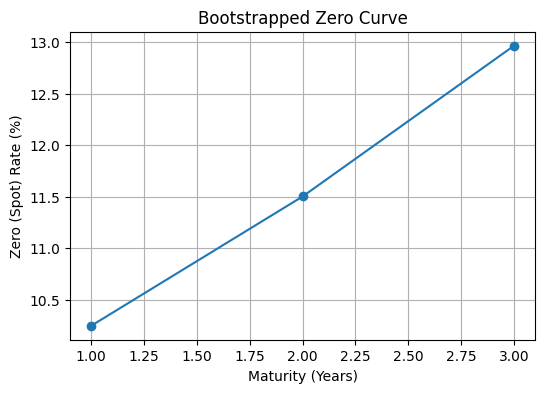

In [8]:
# ============================================
# 5) Zero curve 그래프 (만기 vs spot rate)
# ============================================

mats = df_res["Maturity (Y)"].values
rates = df_res["SpotRate %"].values

plt.figure(figsize=(6,4))
plt.plot(mats, rates, marker="o")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero (Spot) Rate (%)")
plt.title("Bootstrapped Zero Curve")
plt.grid(True)
plt.show()

### 현재 91일 금리 6%, 183일 금리 7%에 형성되어 있다. 91일과 183일 사이에서 거래될 수 있는 선도금리(FRA)는 얼마일까? (1년은 360일로 계산)

In [25]:
# 단순 수익률 개념에 의한 FRA 계산

# 입력 값
r1, r2 = 0.06, 0.07   # 이자율
t1, t2 = 91, 183      # 기간 (일수)
basis = 360           # 기준 일수

# FRA12 계산식
FRA12 = (((1 + r2 * t2 / basis) / (1 + r1 * t1 / basis)) - 1) * (basis / (t2 - t1))
print(FRA12)

0.07869772222737678
